Набір даних:
     місто місяць  температура  опалювальні_дні  витрати_на_опалення
0   Харків    Січ           -6               24                  4.1
1   Харків    Лют           -5               22                  4.0
2   Харків    Бер            1               16                  0.8
3   Харків    Кві           10                7                  1.6
4   Харків    Тра           17                1                  0.0
5   Харків    Чер           20                0                  0.0
6   Харків    Лип           22                0                  0.3
7   Харків    Сер           21                0                  0.4
8   Харків    Вер           15                2                  1.8
9   Харків    Жов            8               11                  1.7
10  Харків    Лис            1               16                  2.5
11  Харків    Гру           -4               22                  2.1

ЗАВДАННЯ 1. ПОБУДОВА РЕГРЕСІЇ
b0 (перетин) = 2.536
b1 (нахил) = -0.111

Рівняння регресії

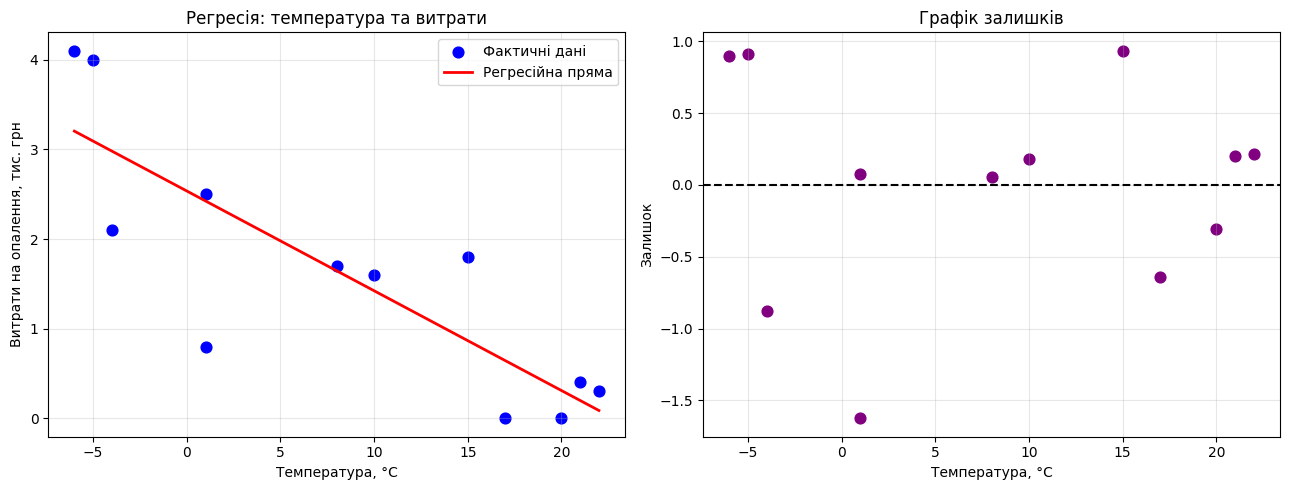


ЗАВДАННЯ 4. ПРОГНОЗ ПРИ -10°C
Прогнозовані витрати при температурі -10°C = 3.648 тис. грн

Фактичний діапазон температур: від -6°C до 22°C
Температура -10°C знаходиться за межами спостережуваного діапазону.
Це екстраполяція, тому прогноз менш надійний, оскільки модель не перевірялася на значеннях температури за межами вибірки.

ЗАВДАННЯ 5. ПОРІВНЯННЯ p-value
p-value linregress = 0.0006635953
p-value pearsonr   = 0.0006635953

Для простої лінійної регресії з одним предиктором гіпотеза H0: b1 = 0 еквівалентна гіпотезі H0: r = 0.
Тому p-value регресії та кореляції Пірсона мають збігатися або бути практично однаковими.

ПІДСУМОК ПРАКТИКИ 17
Місто: Харків
Рівняння: витрати ≈ 2.536 + (-0.111) × температура
R² = 0.702
r Пірсона = -0.838
p-value регресії = 0.000664
p-value кореляції = 0.000664
Прогноз при -10°C = 3.648 тис. грн
Діапазон температур: -6...22°C


In [1]:
# ============================================================
# ПРАКТИКА 17
# Проста лінійна регресія
# Варіант 4 — Харків
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, pearsonr


# ------------------------------------------------------------
# ПОБУДОВА НАБОРУ ДАНИХ
# ------------------------------------------------------------

np.random.seed(4)

city = "Харків"

monthly_temp = [
    -6, -5, 1, 10, 17, 20,
    22, 21, 15, 8, 1, -4
]

months = [
    "Січ", "Лют", "Бер", "Кві",
    "Тра", "Чер", "Лип", "Сер",
    "Вер", "Жов", "Лис", "Гру"
]

rows = []

for month, temp in zip(months, monthly_temp):

    heating_days = np.clip(
        18 - temp + np.random.normal(0, 1.5),
        0,
        30
    )

    heating_days = round(heating_days)

    cost = (
        0.15 * heating_days
        + np.random.normal(0, 1.0)
    )

    cost = round(max(cost, 0), 1)

    rows.append({
        "місто": city,
        "місяць": month,
        "температура": temp,
        "опалювальні_дні": heating_days,
        "витрати_на_опалення": cost
    })

climate = pd.DataFrame(rows)

print("Набір даних:")
print(climate)


# ------------------------------------------------------------
# ЗАВДАННЯ 1
# ПОБУДОВА РЕГРЕСІЙНОЇ МОДЕЛІ
# ------------------------------------------------------------

x = climate["температура"]
y = climate["витрати_на_опалення"]

result = linregress(x, y)

b0 = result.intercept
b1 = result.slope

print("\n" + "=" * 60)
print("ЗАВДАННЯ 1. ПОБУДОВА РЕГРЕСІЇ")
print("=" * 60)

print(f"b0 (перетин) = {b0:.3f}")
print(f"b1 (нахил) = {b1:.3f}")

print(
    f"\nРівняння регресії:"
    f"\nвитрати ≈ {b0:.3f} + ({b1:.3f}) × температура"
)

print(f"\np-value = {result.pvalue:.6f}")

print(
    f"\nПри збільшенні температури на 1°C "
    f"витрати на опалення в середньому змінюються "
    f"на {abs(b1):.3f} тис. грн."
)

if b1 < 0:
    print(
        "Знак нахилу від'ємний, що логічно: "
        "зі зростанням температури потреба в опаленні зменшується."
    )
else:
    print(
        "Знак нахилу додатний."
    )


# ------------------------------------------------------------
# ЗАВДАННЯ 2
# КОЕФІЦІЄНТ ДЕТЕРМІНАЦІЇ R²
# ------------------------------------------------------------

predicted = b0 + b1 * x

residuals = y - predicted

# R² через rvalue²
r2_1 = result.rvalue ** 2

# Сума квадратів залишків
SS_res = np.sum(residuals ** 2)

# Середнє значення Y
y_mean = y.mean()

# Загальна сума квадратів
SS_tot = np.sum((y - y_mean) ** 2)

# R² за формулою
r2_2 = 1 - SS_res / SS_tot

# Кореляція Пірсона
pearson_result = pearsonr(x, y)

r = pearson_result.statistic
r_squared = r ** 2

print("\n" + "=" * 60)
print("ЗАВДАННЯ 2. R²")
print("=" * 60)

print(f"R² через result.rvalue² = {r2_1:.6f}")
print(f"R² через SS_res і SS_tot = {r2_2:.6f}")

print(f"\nSS залишків = {SS_res:.4f}")
print(f"SS загальна = {SS_tot:.4f}")

print(f"\nКореляція Пірсона r = {r:.6f}")
print(f"r² = {r_squared:.6f}")

print(
    f"\nТемпература пояснює приблизно "
    f"{r2_1 * 100:.2f}% розкиду витрат на опалення."
)

print(
    f"Приблизно {(1 - r2_1) * 100:.2f}% "
    f"варіації витрат модель не пояснює."
)


# ------------------------------------------------------------
# ЗАВДАННЯ 3
# ЗАЛИШКИ ТА ГРАФІК
# ------------------------------------------------------------

climate["прогноз"] = predicted
climate["залишок"] = residuals

print("\n" + "=" * 60)
print("ЗАВДАННЯ 3. ЗАЛИШКИ")
print("=" * 60)

print(
    climate[
        [
            "місяць",
            "температура",
            "витрати_на_опалення",
            "прогноз",
            "залишок"
        ]
    ].round(3)
)

print(
    "\nЗалишок = фактичні витрати - передбачені витрати."
)

print(
    "Додатний залишок означає, що фактичні витрати "
    "вищі за прогнозовані."
)

print(
    "Від'ємний залишок означає, що фактичні витрати "
    "нижчі за прогнозовані."
)

# Побудова графіків

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Регресійна пряма

axes[0].scatter(
    x,
    y,
    color="blue",
    s=60,
    label="Фактичні дані"
)

order = np.argsort(x)

axes[0].plot(
    x.iloc[order],
    predicted.iloc[order],
    color="red",
    linewidth=2,
    label="Регресійна пряма"
)

axes[0].set_xlabel("Температура, °C")
axes[0].set_ylabel("Витрати на опалення, тис. грн")
axes[0].set_title("Регресія: температура та витрати")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Графік залишків

axes[1].scatter(
    x,
    residuals,
    color="purple",
    s=60
)

axes[1].axhline(
    0,
    color="black",
    linestyle="--"
)

axes[1].set_xlabel("Температура, °C")
axes[1].set_ylabel("Залишок")
axes[1].set_title("Графік залишків")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# ЗАВДАННЯ 4
# ПРОГНОЗ ПРИ -10°C
# ------------------------------------------------------------

temperature_new = -10

forecast = b0 + b1 * temperature_new

min_temp = climate["температура"].min()
max_temp = climate["температура"].max()

print("\n" + "=" * 60)
print("ЗАВДАННЯ 4. ПРОГНОЗ ПРИ -10°C")
print("=" * 60)

print(
    f"Прогнозовані витрати при температурі "
    f"-10°C = {forecast:.3f} тис. грн"
)

print(
    f"\nФактичний діапазон температур: "
    f"від {min_temp}°C до {max_temp}°C"
)

if min_temp <= temperature_new <= max_temp:

    print(
        "Температура -10°C знаходиться "
        "в межах спостережуваного діапазону."
    )

else:

    print(
        "Температура -10°C знаходиться "
        "за межами спостережуваного діапазону."
    )

    print(
        "Це екстраполяція, тому прогноз менш надійний, "
        "оскільки модель не перевірялася на значеннях "
        "температури за межами вибірки."
    )


# ------------------------------------------------------------
# ЗАВДАННЯ 5
# ПОРІВНЯННЯ p-value РЕГРЕСІЇ ТА КОРЕЛЯЦІЇ
# ------------------------------------------------------------

p_regression = result.pvalue
p_correlation = pearson_result.pvalue

print("\n" + "=" * 60)
print("ЗАВДАННЯ 5. ПОРІВНЯННЯ p-value")
print("=" * 60)

print(
    f"p-value linregress = {p_regression:.10f}"
)

print(
    f"p-value pearsonr   = {p_correlation:.10f}"
)

print(
    "\nДля простої лінійної регресії з одним предиктором "
    "гіпотеза H0: b1 = 0 еквівалентна гіпотезі "
    "H0: r = 0."
)

print(
    "Тому p-value регресії та кореляції Пірсона "
    "мають збігатися або бути практично однаковими."
)


# ------------------------------------------------------------
# ПІДСУМОК
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("ПІДСУМОК ПРАКТИКИ 17")
print("=" * 60)

print(f"Місто: {city}")

print(
    f"Рівняння: "
    f"витрати ≈ {b0:.3f} + ({b1:.3f}) × температура"
)

print(f"R² = {r2_1:.3f}")
print(f"r Пірсона = {r:.3f}")

print(f"p-value регресії = {p_regression:.6f}")
print(f"p-value кореляції = {p_correlation:.6f}")

print(
    f"Прогноз при -10°C = "
    f"{forecast:.3f} тис. грн"
)

print(
    f"Діапазон температур: "
    f"{min_temp}...{max_temp}°C"
)


Чому метод найменших квадратів мінімізує суму квадратів залишків?
Сума самих залишків може дорівнювати нулю через взаємне скорочення додатних і від’ємних помилок. Модулі усувають цю проблему, але квадрати додатково сильніше враховують великі помилки й математично зручні для знаходження оптимальної прямої. Тому мінімізують саме суму квадратів залишків.

Що означає коефіцієнт нахилу
b
1
 і чим він відрізняється від кореляції
r
?
b
1
 показує, на скільки тис. грн у середньому змінюються витрати на опалення при зміні температури на 1°C. Кореляція
r
 показує лише силу та напрямок лінійного зв'язку і не має одиниць вимірювання.

Чому високий
R
2
 не гарантує адекватності лінійної моделі?
Високе
R
2
 показує, що модель пояснює значну частину варіації даних, але не показує форму помилок. Графік залишків може виявити нелінійність, викиди або систематичну структуру. Тому після
R
2
 потрібно обов'язково перевіряти залишки.

Що відбувається з надійністю прогнозу за межами спостереженого діапазону?
Такий прогноз є екстраполяцією. Його надійність нижча, оскільки модель будувалася лише на спостережуваному діапазоні й немає гарантії, що залежність за його межами залишиться лінійною. Чем далі значення
x
 від фактичних даних, тим обережніше треба ставитися до прогнозу.